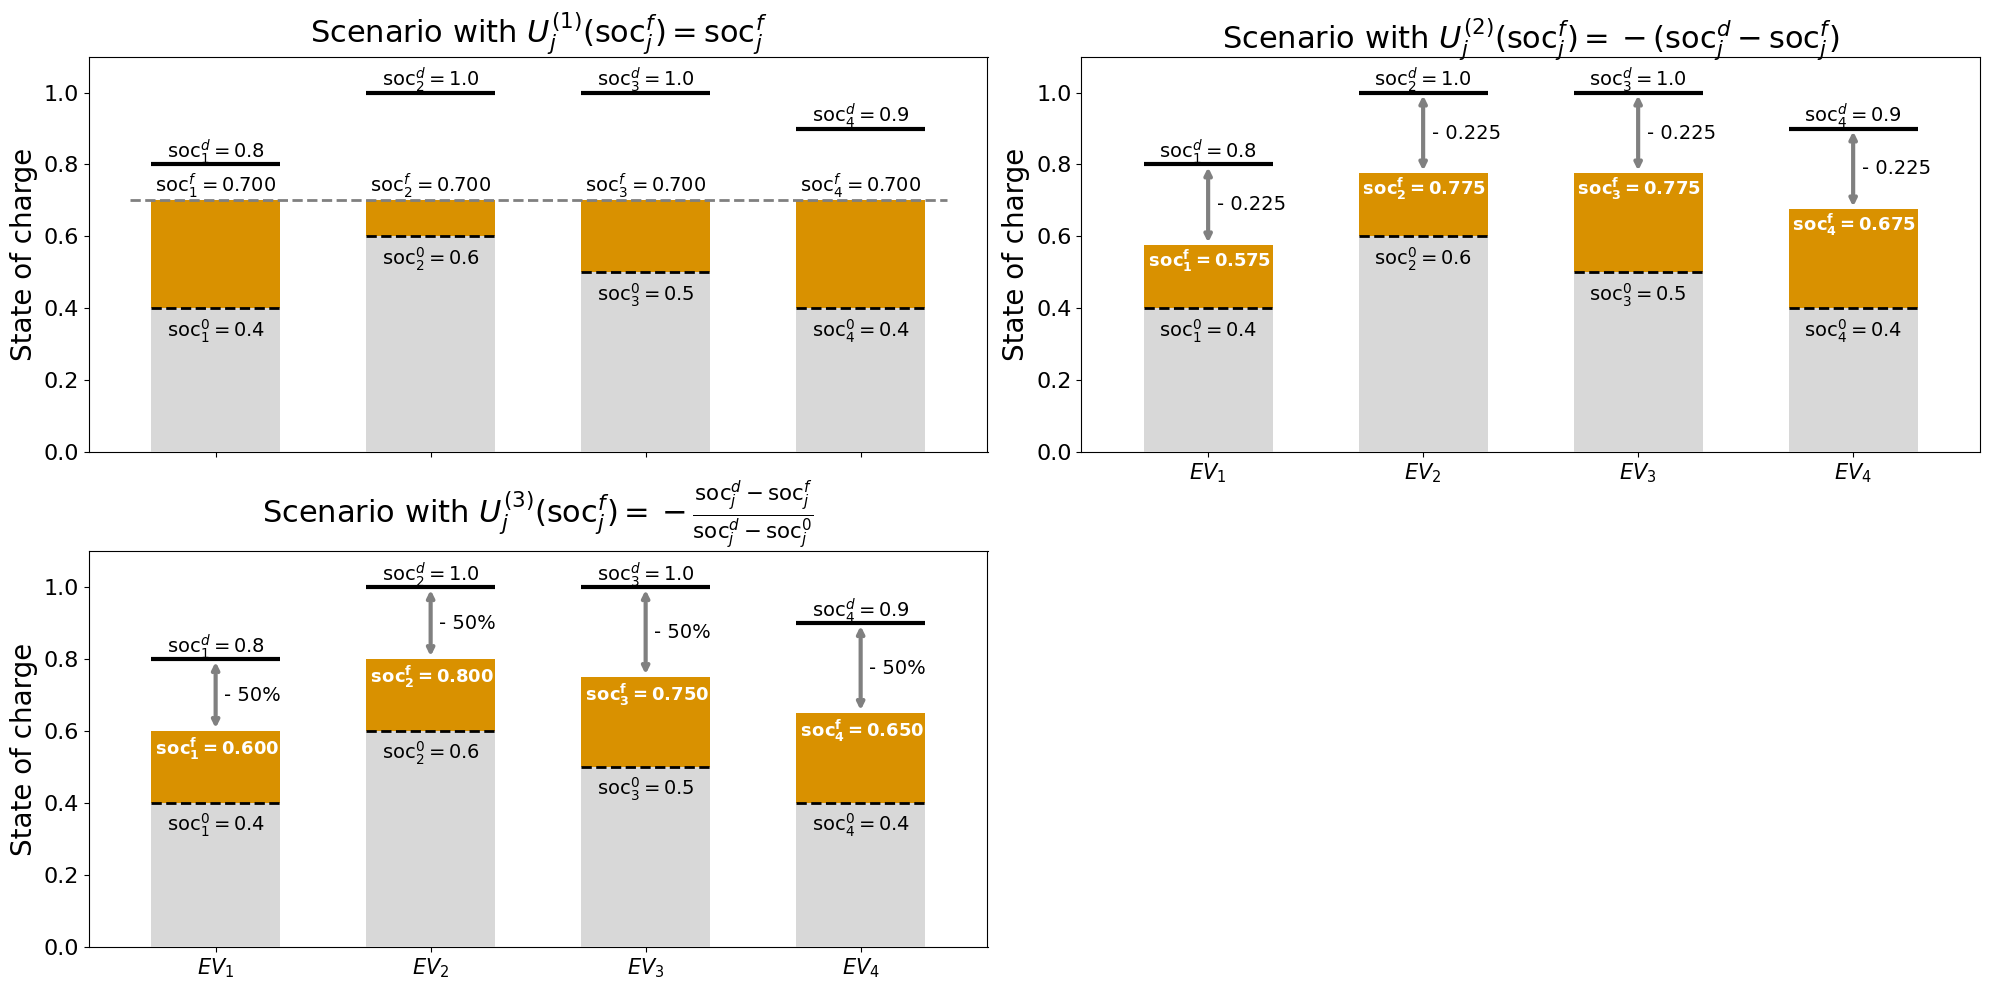

In [2]:
import matplotlib.pyplot as plt
import numpy as np

labels = [r'$EV_1$', r'$EV_2$', r'$EV_3$', r'$EV_4$']
x = np.arange(len(labels))
width = 0.6

soc_0 = np.array([0.4, 0.6, 0.5, 0.4])
soc_d = np.array([0.8, 1.0, 1.0, 0.9])

# Scenario 1  – equal final SoC: U^(1)
soc_f_u1 = np.array([0.7, 0.7, 0.7, 0.7])

# Scenario 2 – minimise absolute short‑fall: U^(2)
soc_f_u2 = np.array([0.575, 0.775, 0.775, 0.675])

# Scenario 3 – minimise relative short‑fall: U^(3)
soc_f_u3 = np.array([0.6, 0.8, 0.75, 0.65])

scenarios = [
    (soc_f_u1, r'Scenario with $U^{(1)}_j (\mathrm{soc}^f_j) = \mathrm{soc}^f_j$'),
    (soc_f_u2, r'Scenario with $U^{(2)}_j (\mathrm{soc}^f_j) = -(\mathrm{soc}^d_j - \mathrm{soc}^f_j)$'),
    (soc_f_u3, r'Scenario with $U^{(3)}_j (\mathrm{soc}^f_j) = -\frac{\mathrm{soc}^d_j - \mathrm{soc}^f_j}{\mathrm{soc}^d_j - \mathrm{soc}^0_j}$'),
]

fig, axes = plt.subplots(2, 2, figsize=(20, 10), sharex=True)
axes_flat = axes.flatten()

for scn, (ax, (soc_f, title)) in enumerate(zip(axes_flat, scenarios)):
    bars = ax.bar(x, soc_f, width, color='#d99100', zorder=2)
    ax.bar(x, soc_0, width, color='#d8d8d8', zorder=3)

    ax.set_title(f'{title}', fontsize=22)
    ax.set_ylabel('State of charge', fontsize=20)
    ax.set_ylim(0, 1.1)
    ax.set_xticks(x, fontsize=15)
    ax.set_xticklabels(labels, fontsize=15)
    ax.tick_params(axis='y', labelsize=16)

    if scn == 1:
        ax.tick_params(axis='x', labelbottom=True)

    for i, (desired, initial) in enumerate(zip(soc_d, soc_0)):
        center = x[i]
        ax.hlines(desired, center - width / 2, center + width / 2,
                  colors='black', linewidth=3, zorder=4)
        ax.hlines(initial, center - width / 2, center + width / 2,
                  colors='black', linewidth=2, linestyles='dashed', zorder=4)

        ax.text(center, initial - 0.025, rf'$\mathrm{{soc}}^0_{i+1} = {initial:.1f}$',
                ha='center', va='top', fontsize=14, color='black')
        
        ax.text(center, desired + 0.075, rf'$\mathrm{{soc}}^d_{i+1} = {desired:.1f}$',
                ha='center', va='top', fontsize=14, color='black')

    for i, bar in enumerate(bars):
        h     = bar.get_height()
        init  = soc_0[i]
        gap   = (soc_d[i] - h) / (soc_d[i] - init)
        gap_abs = soc_d[i] - h
        mid_y = (h + init) / 2
        mid_y_abs = (soc_d[i] + h) / 2
        mid_x = bar.get_x() + bar.get_width() / 2

        if(scn == 2):
            ax.text(mid_x, h - 0.085, rf'$\,\mathbf{{\mathrm{{\mathbf{{soc}}}}^f_{i+1} = {h:.3f}}}\,$',
                    ha='center', va='bottom', fontsize=13, color='white')
            ax.annotate('', xy=(mid_x, soc_d[i]), xytext=(mid_x, h),
                        arrowprops=dict(arrowstyle='<->', lw=3, color='grey'))
            ax.text(mid_x + width * 0.025 + 0.025, mid_y_abs, f'- {gap:.0%}',
                    ha='left', va='center', fontsize=14, color='black')
        elif(scn == 1):
            ax.text(mid_x, h - 0.08, rf'$\,\mathbf{{\mathrm{{\mathbf{{soc}}}}^f_{i+1} = {h:.3f}}}\,$',
                    ha='center', va='bottom', fontsize=13, color='white')
            ax.annotate('', xy=(mid_x, soc_d[i]), xytext=(mid_x, h),
                        arrowprops=dict(arrowstyle='<->', lw=3, color='grey'))
            ax.text(mid_x + width * 0.025 + 0.025, mid_y_abs, f'- {gap_abs:.3f}',
                    ha='left', va='center', fontsize=14, color='black')
        elif(scn == 0):
            ax.text(mid_x, h + 0., rf'$\mathrm{{soc}}^f_{i+1} = {h:.3f}$',
                    ha='center', va='bottom', fontsize=14)
    
    if(scn == 0):
        ax.hlines(soc_f[0], -0.4, 3.4,
                  colors='grey', linewidth=2, linestyles='dashed', zorder=5)

for idx in range(len(scenarios), len(axes_flat)):
    axes_flat[idx].axis('off')

import matplotlib.lines as mlines
desired_handle = mlines.Line2D([], [], color='black', linewidth=3, label=r'Desired $\mathrm{soc}^d_j$')
initial_handle = mlines.Line2D([], [], color='grey', linewidth=3, linestyle='dashed', label=r'Initial $\mathrm{soc}^0_j$')

fig.tight_layout()
fig.savefig("charging_utilities_example.png", dpi=300, bbox_inches="tight")
plt.show()

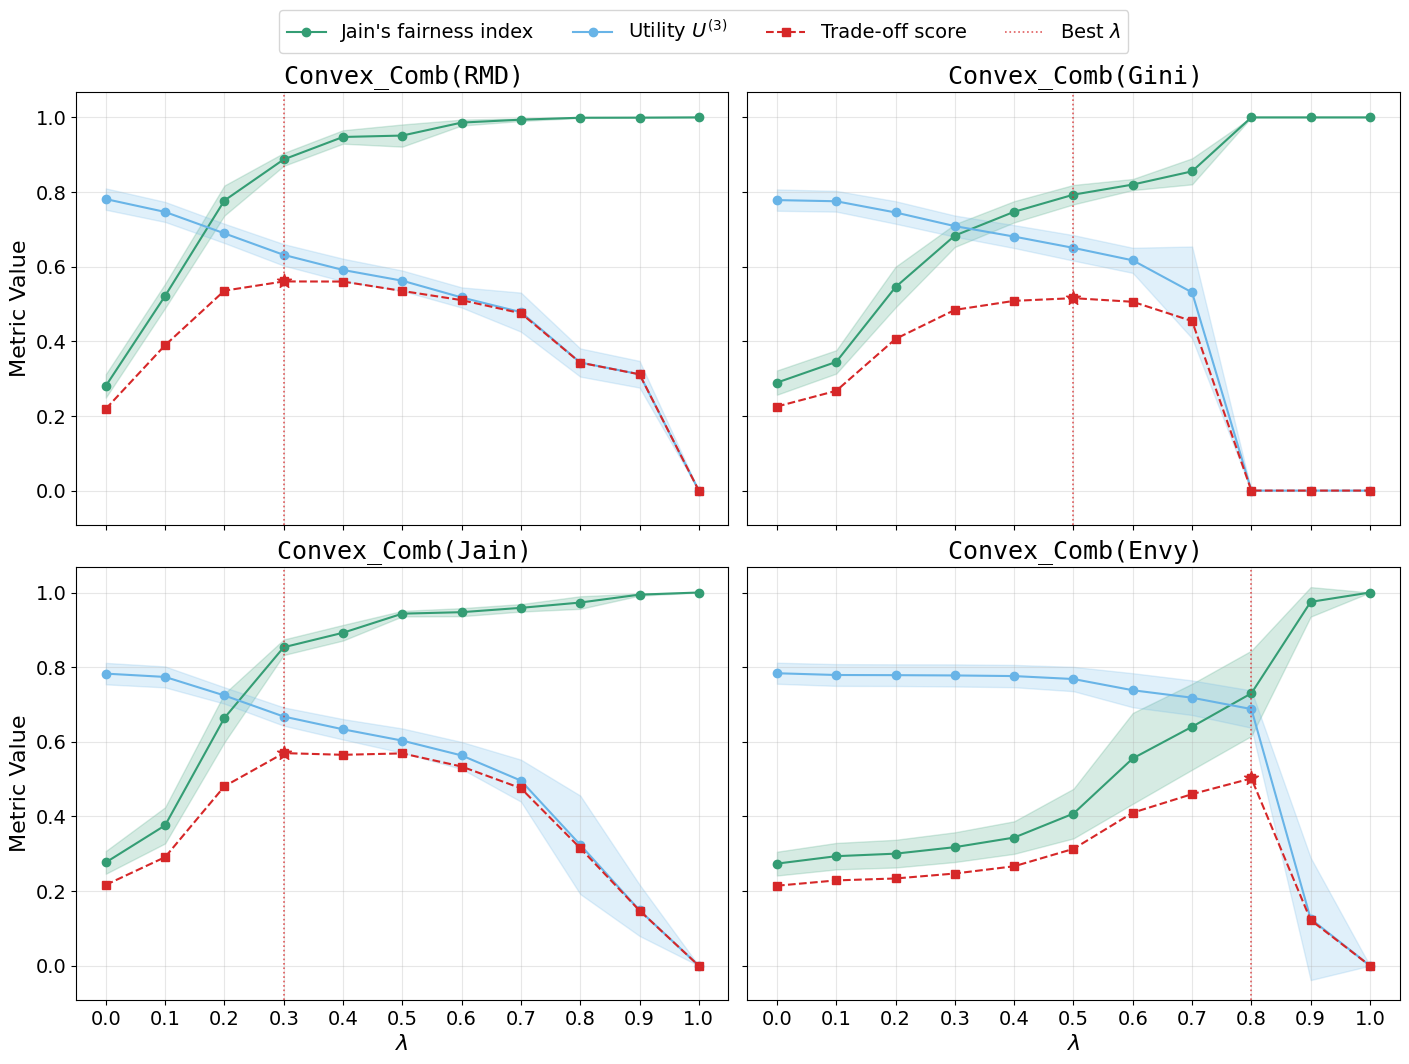

Saved: fairness_utility_tradeoff_grid_comb.png


In [ ]:
import math
import re
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt

FAIRNESS_COLOR = "#349d74"
UTILITY_COLOR = "#68b4e7"
TRADEOFF_COLOR = "#d62728"
FILE_PATTERN = re.compile(
    r"solution_(?P<instance>\d+)_obj=(?P<obj>\d+)_lambda=(?P<lambda>\d+(?:\.\d+)?)_comb\.log$"
)
ALLOWED_SCENARIOS = set(range(1, 6)) | set(range(11, 16)) | set(range(21, 26))
ALLOWED_OBJECTIVES = set(range(5, 9))
ALLOWED_LAMBDAS = {i / 10 for i in range(11)}
LAMBDA_TOL = 1e-9
TITLE_FONTSIZE = 18
AXIS_LABEL_FONTSIZE = 16
TICK_LABEL_FONTSIZE = 14
LEGEND_FONTSIZE = 14

OBJECTIVE_NAMES = [
    r'$\mathtt{Utilitarian}$', r'$\mathtt{Quadratic}$',
    '$\\mathtt{Proportional\\ Fairness}$', '$\\mathtt{Harmonic\\ Fairness}$',
    '$\\mathtt{Max}$-$\\mathtt{Min}$', r'$\mathtt{Convex\_Comb (RMD)}$',
    r'$\mathtt{Convex\_Comb (Gini)}$', r'$\mathtt{Convex\_Comb (Jain)}$',
    r'$\mathtt{Convex\_Comb (Envy)}$', '$\\mathtt{Egalitarian}$\n$\\mathtt{(No\\ Charging)}$'
]


def _summarize(values):
    vals = [v for v in values if math.isfinite(v)]
    n = len(vals)
    if n == 0:
        return math.nan, math.nan, 0
    mean = sum(vals) / n
    if n == 1:
        return mean, 0.0, n
    var = sum((v - mean) ** 2 for v in vals) / (n - 1)
    std = math.sqrt(var)
    ci = 1.96 * std / math.sqrt(n)
    return mean, ci, n


def _best_index(values):
    best_idx, best_val = None, -math.inf
    for i, v in enumerate(values):
        if math.isfinite(v) and v > best_val:
            best_val, best_idx = v, i
    return best_idx


def _is_allowed_lambda(value):
    return any(math.isclose(value, a, abs_tol=LAMBDA_TOL) for a in ALLOWED_LAMBDAS)


def _parse_list_cell(cell):
    if isinstance(cell, list):
        return [float(x) for x in cell]
    if not isinstance(cell, str):
        return []
    s = cell.strip()
    if s.startswith("[") and s.endswith("]"):
        s = s[1:-1]
    if not s:
        return []
    return [float(x) for x in s.split(",") if x.strip()]


def compute_metrics_from_socs(row):
    soc_0 = _parse_list_cell(row.get("initial_soc_list"))
    soc_d = _parse_list_cell(row.get("desired_soc_list"))
    soc_f = _parse_list_cell(row.get("final_soc_list"))

    if not soc_0 or not soc_d or not soc_f:
        return math.nan, math.nan
    if not (len(soc_0) == len(soc_d) == len(soc_f)):
        return math.nan, math.nan

    fair_vals = []
    util_vals = []
    for s0, sd, sf in zip(soc_0, soc_d, soc_f):
        denom = sd - s0
        if denom <= 0.0:
            continue
        shortfall = (sd - sf) / denom
        fair_vals.append(-shortfall)
        util_vals.append(1.0 - shortfall)

    fair_vals = [u for u in fair_vals if math.isfinite(u)]
    util_vals = [u for u in util_vals if math.isfinite(u)]
    if not fair_vals or not util_vals:
        return math.nan, math.nan

    sum_u = sum(fair_vals)
    sum_u2 = sum(u * u for u in fair_vals)
    if sum_u2 > 0.0:
        jain = (sum_u * sum_u) / (len(fair_vals) * sum_u2)
    else:
        jain = 1.0
    mean_utility = sum(util_vals) / len(util_vals)
    return jain, mean_utility


def parse_filename(name):
    if not isinstance(name, str):
        return None, None, None
    m = FILE_PATTERN.match(name.strip())
    if not m:
        return None, None, None
    return int(m.group("instance")), int(m.group("obj")), float(m.group("lambda"))


df = pd.read_csv("output_pre_cc.csv")
required = {"Filename", "initial_soc_list", "desired_soc_list", "final_soc_list"}
missing = required.difference(df.columns)
if missing:
    raise ValueError(f"output_pre_cc.csv is missing required columns: {sorted(missing)}")

df[["_instance", "_obj", "_lambda"]] = df["Filename"].apply(lambda x: pd.Series(parse_filename(x)))
df = df.dropna(subset=["_instance", "_obj", "_lambda"]).copy()

df = df[
    df["_instance"].isin(ALLOWED_SCENARIOS)
    & df["_obj"].isin(ALLOWED_OBJECTIVES)
    & df["_lambda"].apply(_is_allowed_lambda)
].copy()


if df["Filename"].duplicated().any():
    df = df.sort_values(["_instance", "_obj", "Filename"], kind="stable").reset_index(drop=True)
    df["_cand_idx"] = df.groupby(["_instance", "_obj", "Filename"], sort=False).cumcount()
    lambda_to_idx = {i / 10: i for i in range(11)}
    df["_lam_idx"] = df["_lambda"].round(1).map(lambda_to_idx)

    aligned = df[df["_cand_idx"] == df["_lam_idx"]].copy()
    if aligned.empty:
        raise ValueError("Could not align SoC rows to lambda values from output_pre_cc.csv")
else:
    aligned = df.drop_duplicates(subset=["Filename"], keep="last").copy()

aligned[["jain_from_socs", "utility_from_socs"]] = aligned.apply(
    lambda r: pd.Series(compute_metrics_from_socs(r)), axis=1
)

by_obj = defaultdict(lambda: defaultdict(list))
for _, r in aligned.iterrows():
    obj = int(r["_obj"])
    lam = float(r["_lambda"])
    j = r["jain_from_socs"]
    u = r["utility_from_socs"]
    if math.isfinite(j) and math.isfinite(u):
        by_obj[obj][lam].append((j, u))

if not by_obj:
    raise ValueError("No valid rows in output_pre_cc.csv after filtering + SoC metric recomputation")


def summaries_for_objective(grouped):
    lambdas = sorted(grouped.keys())
    jain_means, jain_cis, util_means, util_cis = [], [], [], []
    for lam in lambdas:
        j_vals = [v[0] for v in grouped[lam]]
        u_vals = [v[1] for v in grouped[lam]]
        j_mean, j_ci, _ = _summarize(j_vals)
        u_mean, u_ci, _ = _summarize(u_vals)
        jain_means.append(j_mean)
        jain_cis.append(j_ci)
        util_means.append(u_mean)
        util_cis.append(u_ci)

    trade_geo = [
        f * u
        if (math.isfinite(f) and math.isfinite(u) and f >= 0.0 and u >= 0.0)
        else math.nan
        for f, u in zip(jain_means, util_means)
    ]
    return lambdas, jain_means, jain_cis, util_means, util_cis, trade_geo


out_path = Path("fairness_utility_tradeoff_grid_comb.png")
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True, constrained_layout=True)
obj_order = [5, 6, 7, 8]
xticks = sorted(ALLOWED_LAMBDAS)
legend_handles, legend_labels = None, None


def objective_label(obj):
    idx = int(obj)
    return OBJECTIVE_NAMES[idx] if 0 <= idx < len(OBJECTIVE_NAMES) else f"Objective {obj}"


for idx, obj in enumerate(obj_order):
    ax = axes[idx // 2][idx % 2]
    title = objective_label(obj)

    if obj not in by_obj:
        ax.set_title(f"{title} (no data)", fontsize=TITLE_FONTSIZE)
        ax.tick_params(axis="both", labelsize=TICK_LABEL_FONTSIZE)
        ax.grid(True, alpha=0.3)
        continue

    lambdas, jain_means, jain_cis, util_means, util_cis, trade_geo = summaries_for_objective(by_obj[obj])

    ax.plot(lambdas, jain_means, marker="o", color=FAIRNESS_COLOR, label="Jain's fairness index")
    ax.fill_between(
        lambdas,
        [m - c for m, c in zip(jain_means, jain_cis)],
        [m + c for m, c in zip(jain_means, jain_cis)],
        color=FAIRNESS_COLOR,
        alpha=0.2,
    )
    ax.plot(lambdas, util_means, marker="o", color=UTILITY_COLOR, label=r"Utility $U^{(3)}$")
    ax.fill_between(
        lambdas,
        [m - c for m, c in zip(util_means, util_cis)],
        [m + c for m, c in zip(util_means, util_cis)],
        color=UTILITY_COLOR,
        alpha=0.2,
    )
    ax.plot(lambdas, trade_geo, marker="s", linestyle="--", color=TRADEOFF_COLOR, label="Trade-off score")

    best_idx = _best_index(trade_geo)
    if best_idx is not None:
        best_lambda, best_score = lambdas[best_idx], trade_geo[best_idx]
        line_label = r"Best $\lambda$" if idx == 0 else "_nolegend_"
        ax.axvline(best_lambda, color=TRADEOFF_COLOR, linestyle=":", linewidth=1.2, alpha=0.75, label=line_label)
        ax.scatter([best_lambda], [best_score], color=TRADEOFF_COLOR, marker="*", s=110, zorder=5)

    ax.set_title(title, fontsize=TITLE_FONTSIZE)
    ax.set_xticks(xticks)
    ax.tick_params(axis="both", labelsize=TICK_LABEL_FONTSIZE)
    ax.grid(True, alpha=0.3)
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

for ax in axes[1]:
    ax.set_xlabel(r"$\lambda$", fontsize=AXIS_LABEL_FONTSIZE)
for ax in (axes[0][0], axes[1][0]):
    ax.set_ylabel("Metric Value", fontsize=AXIS_LABEL_FONTSIZE)

if legend_handles and legend_labels:
    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.06),
        ncol=4,
        fontsize=LEGEND_FONTSIZE,
    )

fig.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0.2)
plt.show()
print(f"Saved: {out_path}")

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

OBJECTIVE_NAMES = [
    'Utilitarian', 'Quadratic', 'Proportional Fairness', 'Harmonic Fairness',
    'Max-Min', 'Convex_Comb (RMD)',
    'Convex_Comb (Gini)', 'Convex_Comb (Jain)',
    'Convex_Comb (Envy)', 'Egalitarian\n(No Charging)'
]


def load_method_csv(path):
    csv_path = Path(path)
    if not csv_path.is_file():
        raise FileNotFoundError(
            f"Missing {csv_path}. Run the first cell to generate output CSV files."
        )

    df = pd.read_csv(csv_path)

    if 'Group' not in df.columns and 'Instance_Number' in df.columns:
        instance_num = pd.to_numeric(df['Instance_Number'], errors='coerce')
        df['Group'] = ((instance_num - 1) // 10 + 1).astype('Int64')

    if 'Objective_Index' in df.columns:
        df['Objective_Index'] = pd.to_numeric(df['Objective_Index'], errors='coerce')

    return df


def analyze_gap_results(df, map_objective_index_to_name):
    df = df.copy()
    df['Additional infos_computation_time'] = df['Additional infos_computation_time'].clip(upper=3600)

    expected_scenarios = 10
    result_stats = []
    all_objective_indices = list(range(len(map_objective_index_to_name)))

    for objective_idx in all_objective_indices:
        obj_data = df[df['Objective_Index'] == objective_idx]
        actual_scenarios = obj_data.shape[0]
        nan_gaps_count = obj_data['Additional infos_gap'].isna().sum()

        if actual_scenarios > 0:
            comp_time_mean = obj_data['Additional infos_computation_time'].mean()
            comp_time_std = obj_data['Additional infos_computation_time'].std()
            comp_time_median = obj_data['Additional infos_computation_time'].median()

            if actual_scenarios < expected_scenarios:
                missing_count = expected_scenarios - actual_scenarios
                adjusted_times = list(obj_data['Additional infos_computation_time']) + [3600] * missing_count
                comp_time_mean = np.mean(adjusted_times)
                comp_time_std = np.std(adjusted_times)
                if missing_count > expected_scenarios / 2:
                    comp_time_median = 3600

            gap_mean = obj_data['Additional infos_gap'].mean()
            gap_std = obj_data['Additional infos_gap'].std()
            gap_median = obj_data['Additional infos_gap'].median()
            obj_value_mean = obj_data['Additional infos_obj'].mean()
            gap_formatted = f"{gap_mean * 100:.2f}% ± {gap_std * 100:.2f}% (Median: {gap_median * 100:.2f}%)"
        else:
            comp_time_mean = 3600
            comp_time_std = 0
            comp_time_median = 3600
            gap_mean = float('nan')
            gap_std = float('nan')
            gap_median = float('nan')
            obj_value_mean = float('nan')
            gap_formatted = 'N/A'
            nan_gaps_count = 0

        comp_time_formatted = f"{comp_time_mean:.2f} ± {comp_time_std:.2f} (Median: {comp_time_median:.2f})"

        result_stats.append({
            'Objective_Index': objective_idx,
            'Computation_Time_Mean': comp_time_mean,
            'Computation_Time_Std': comp_time_std,
            'Computation_Time_Median': comp_time_median,
            'Gap_Mean': gap_mean,
            'Gap_Std': gap_std,
            'Gap_Median': gap_median,
            'Objective_Value_Mean': obj_value_mean,
            'Scenarios_Found': actual_scenarios,
            'Scenarios_Missing': expected_scenarios - actual_scenarios,
            'NaN_Gaps_Count': nan_gaps_count,
            'Computation_Time': comp_time_formatted,
            'Gap': gap_formatted,
        })

    grouped_stats = pd.DataFrame(result_stats).sort_values('Objective_Index')
    grouped_stats = grouped_stats.rename(columns={'Objective_Index': 'Objective'})
    grouped_stats['Objective'] = grouped_stats['Objective'].map(lambda x: map_objective_index_to_name[x])

    return grouped_stats[['Objective', 'Computation_Time', 'Gap', 'Scenarios_Found', 'Scenarios_Missing', 'NaN_Gaps_Count']]


df_mip = load_method_csv('output_mip.csv')
df_h = load_method_csv('output_h.csv')
df_h_lns = load_method_csv('output_h_lns.csv')
df_h_lns_mip = load_method_csv('output_h_lns_mip.csv')

print('MM Results:')
print()
for g in range(1, 7):
    print(f"Results for Group {g}:")
    print(analyze_gap_results(df_mip[df_mip['Group'] == g], OBJECTIVE_NAMES))
    print('-' * 30)

print()
print('=' * 50)
print()
print('H Results:')
print()
for g in range(1, 7):
    print(f"Results for Group {g}:")
    print(analyze_gap_results(df_h[df_h['Group'] == g], OBJECTIVE_NAMES))
    print('-' * 30)

print()
print('=' * 50)
print()
print('H+LNS Results:')
print()
for g in range(1, 7):
    print(f"Results for Group {g}:")
    print(analyze_gap_results(df_h_lns[df_h_lns['Group'] == g], OBJECTIVE_NAMES))
    print('-' * 30)

print()
print('=' * 50)
print()
print('H+LNS+MM Results:')
print()
for g in range(1, 7):
    print(f"Results for Group {g}:")
    print(analyze_gap_results(df_h_lns_mip[df_h_lns_mip['Group'] == g], OBJECTIVE_NAMES))
    print('-' * 30)

MM Results:

Results for Group 1:
                    Objective                  Computation_Time  \
0                 Utilitarian  3600.00 ± 0.00 (Median: 3600.00)   
1                   Quadratic  3600.00 ± 0.00 (Median: 3600.00)   
2       Proportional Fairness  3600.00 ± 0.00 (Median: 3600.00)   
3           Harmonic Fairness  3600.00 ± 0.00 (Median: 3600.00)   
4                     Max-Min  3600.00 ± 0.00 (Median: 3600.00)   
5           Convex_Comb (RMD)  3600.00 ± 0.00 (Median: 3600.00)   
6          Convex_Comb (Gini)  3600.00 ± 0.00 (Median: 3600.00)   
7          Convex_Comb (Jain)  3600.00 ± 0.00 (Median: 3600.00)   
8          Convex_Comb (Envy)  3600.00 ± 0.00 (Median: 3600.00)   
9  Egalitarian\n(No Charging)  3600.00 ± 0.00 (Median: 3600.00)   

                                      Gap  Scenarios_Found  Scenarios_Missing  \
0           9.07% ± 3.78% (Median: 8.07%)               10                  0   
1        66.65% ± 17.45% (Median: 72.82%)               10        

Plotting combined groups


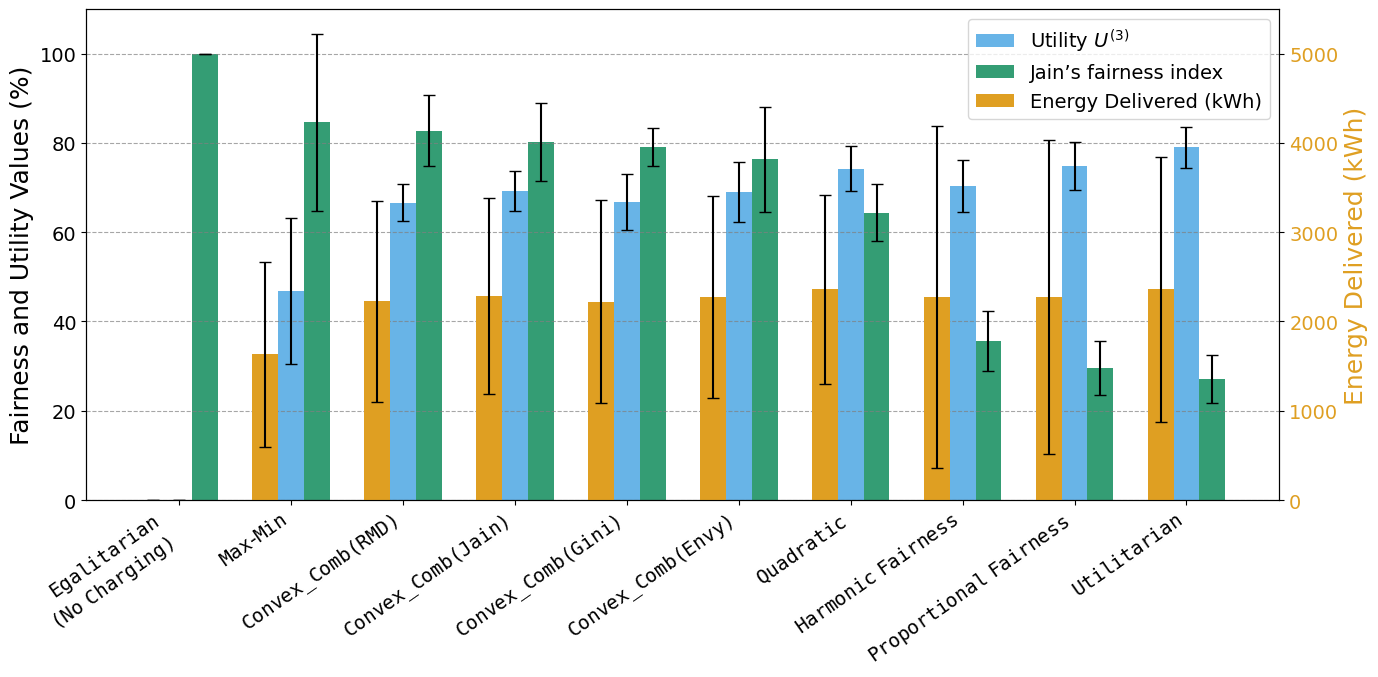

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

OBJECTIVE_NAMES = [
    r'$\mathtt{Utilitarian}$', r'$\mathtt{Quadratic}$',
    '$\\mathtt{Proportional\\ Fairness}$', '$\\mathtt{Harmonic\\ Fairness}$',
    '$\\mathtt{Max}$-$\\mathtt{Min}$', r'$\mathtt{Convex\_Comb (RMD)}$',
    r'$\mathtt{Convex\_Comb (Gini)}$', r'$\mathtt{Convex\_Comb (Jain)}$',
    r'$\mathtt{Convex\_Comb (Envy)}$', '$\\mathtt{Egalitarian}$\n$\\mathtt{(No\\ Charging)}$'
]

def plot_energy_utility_fairness_combined(df_soc, df_metrics, map_objective_index_to_name, group_id=None, verbose=True):
    """
    Left y-axis: Energy Delivered (kWh) with std (green).
    Right y-axis: Utility (U^3) and Jain's fairness index with std (blue, orange).
    Ordering and renaming follow the utility/fairness reference code.
    """

    df_soc = df_soc.copy()
    if group_id is not None:
        df_soc = df_soc[df_soc['group'] == group_id].copy()

    list_cols = ['final_soc_list', 'initial_soc_list', 'desired_soc_list', 'battery_capacity_list']
    for col in list_cols:
        if col not in df_soc.columns:
            print(f"Error: Required column '{col}' not found.")
            return
        df_soc[col] = df_soc[col].apply(
            lambda s: [float(x) for x in str(s).split(',')] if pd.notna(s) else []
        )
    if verbose:
        print(f"Rows before explode: {len(df_soc)}")

    df_long = df_soc.explode(list_cols).copy()
    df_long.rename(columns={
        'final_soc_list': 'final_soc',
        'initial_soc_list': 'initial_soc',
        'desired_soc_list': 'desired_soc',
        'battery_capacity_list': 'battery_capacity_kwh'
    }, inplace=True)

    numeric_cols = ['final_soc', 'initial_soc', 'desired_soc', 'battery_capacity_kwh']
    for col in numeric_cols:
        df_long[col] = pd.to_numeric(df_long[col], errors='coerce')
    df_long.dropna(subset=numeric_cols, inplace=True)

    if verbose:
        print(f"Rows after explode & cleanup: {len(df_long)}")
        print(f"Non-NaN counts -> final_soc: {df_long['final_soc'].notna().sum()}, "
              f"initial_soc: {df_long['initial_soc'].notna().sum()}, "
              f"desired_soc: {df_long['desired_soc'].notna().sum()}, "
              f"battery_capacity_kwh: {df_long['battery_capacity_kwh'].notna().sum()}")

    df_long['energy'] = (df_long['final_soc'] - df_long['initial_soc']) * df_long['battery_capacity_kwh']

    energy_agg = df_long.groupby('Objective_Index', as_index=False).agg(
        energy_mean=('energy', 'mean'),
        energy_std=('energy', 'std'),
        energy_sem=('energy', 'sem')
    )
    if verbose:
        print(f"Rows after energy aggregation (unique objectives): {len(energy_agg)}")
    

    if not set(energy_agg['Objective_Index']).intersection(df_metrics['Objective_Index'].unique()):
        if verbose:
            print("Detected index offset between SOC and metrics files.")
        energy_agg['Objective_Index'] = energy_agg['Objective_Index']

    dfm = df_metrics.copy()
    if verbose:
        print(f"Rows before aggregation (metrics): {len(dfm)}")
        util_non_nan = dfm['Metrics_Utility'].notna().sum()
        fair_non_nan = dfm["Metrics_Jain's Fairness Index"].notna().sum()
        print(f"Non-NaN before aggregation -> Utility: {util_non_nan}, Fairness: {fair_non_nan}")

    agg_results = dfm.groupby('Objective_Index', as_index=False).agg({
        "Metrics_Utility": lambda s: 100. - s.mean(skipna=True) * 100,
        "Metrics_Jain's Fairness Index": lambda s: s.mean(skipna=True) * 100,
    })
    std_results = dfm.groupby('Objective_Index', as_index=False).agg({
        "Metrics_Utility": lambda s: s.std(skipna=True) * 100,
        "Metrics_Jain's Fairness Index": lambda s: s.std(skipna=True) * 100,
    }).rename(columns={
        "Metrics_Utility": "Metrics_Utility_Std",
        "Metrics_Jain's Fairness Index": "Metrics_Jain's Fairness Index_Std",
    })
    agg_results = agg_results.merge(std_results, on='Objective_Index', how='left')

    if verbose:
        print(f"Rows after metrics aggregation (unique objectives): {len(agg_results)}")

    energy_agg['Objective_Index'] = pd.to_numeric(energy_agg['Objective_Index'], errors='coerce').astype('Int64')
    agg_results['Objective_Index'] = pd.to_numeric(agg_results['Objective_Index'], errors='coerce').astype('Int64')

    custom_order = [
        '$\mathtt{Egalitarian}$\n$\mathtt{(No\ Charging)}$', '$\mathtt{Max}$-$\mathtt{Min}$',
        r'$\mathtt{Convex\_Comb (RMD)}$', r'$\mathtt{Convex\_Comb (Jain)}$',
        r'$\mathtt{Convex\_Comb (Gini)}$', r'$\mathtt{Convex\_Comb (Envy)}$', r'$\mathtt{Quadratic}$',
        '$\mathtt{Harmonic\ Fairness}$', '$\mathtt{Proportional\ Fairness}$', r'$\mathtt{Utilitarian}$'
    ]
    custom_order_idx = [9, 4, 5, 7, 6, 8, 1, 3, 2, 0]
    objective_label_by_idx = {idx: label for idx, label in zip(custom_order_idx, custom_order)}

    metrics_plot = agg_results[agg_results['Objective_Index'].isin(custom_order_idx)].copy()
    metrics_plot['Objective'] = metrics_plot['Objective_Index'].map(objective_label_by_idx)

    present_idx = set(metrics_plot['Objective_Index'].dropna().astype(int).tolist())
    final_idx_order = [idx for idx in custom_order_idx if idx in present_idx]
    final_order = [objective_label_by_idx[idx] for idx in final_idx_order]

    metrics_plot['Objective'] = pd.Categorical(metrics_plot['Objective'], categories=final_order, ordered=True)
    metrics_plot = metrics_plot.sort_values('Objective').reset_index(drop=True)

    merged = metrics_plot.merge(energy_agg, on='Objective_Index', how='left')
    merged = merged.sort_values('Objective').reset_index(drop=True)

    if verbose:
        print(f"Plotted objectives: {list(merged['Objective'])}")

    fig, ax1 = plt.subplots(figsize=(14, 7))
    ax2 = ax1.twinx()

    n = len(merged)
    group_spacing = 1.3
    x = np.arange(n) * group_spacing
    bar_width = 0.30

    bars_energy = ax2.bar(
        x - bar_width, merged['energy_mean'],
        yerr=merged['energy_std'].fillna(0),
        width=bar_width,
        label='Energy Delivered (kWh)',
        color="#df9f22",
        capsize=4
    )

    bars_utility = ax1.bar(
        x,
        merged["Metrics_Utility"],
        yerr=merged["Metrics_Utility_Std"].fillna(0),
        width=bar_width,
        label=r'Utility $U^{(3)}$',
        color="#68b4e7",
        capsize=4
    )

    bars_jain = ax1.bar(
        x + bar_width,
        merged["Metrics_Jain's Fairness Index"],
        yerr=merged["Metrics_Jain's Fairness Index_Std"].fillna(0),
        width=bar_width,
        label="Jain’s fairness index",
        color="#349d74",
        capsize=4
    )

    ax2.set_ylabel("Energy Delivered (kWh)", fontsize=18, color='#df9f22')
    ax1.set_ylabel("Fairness and Utility Values (%)", fontsize=18)
    ax2.tick_params(axis='y', labelcolor='#df9f22', labelsize=14)
    ax2.set_ylim(0, 5500)
    ax1.set_ylim(0, 110)
    ax1.tick_params(axis='y', labelsize=14)

    y1_min, y1_max = ax2.get_ylim()
    y2_min, y2_max = ax1.get_ylim()
    ratio1 = abs(y1_min / y1_max) if y1_max != 0 and y1_min < 0 else 0
    ratio2 = abs(y2_min / y2_max) if y2_max != 0 and y2_min < 0 else 0
    max_ratio = max(ratio1, ratio2)
    if max_ratio > 0:
        if y1_max > 0: ax1.set_ylim(bottom=-max_ratio * y1_max)
        if y2_max > 0: ax2.set_ylim(bottom=-max_ratio * y2_max)

    ax1.set_xticks(x)
    ax1.set_xticklabels(merged["Objective"], rotation=35, ha="right", fontsize=14)

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right", fontsize=14)

    ax1.grid(axis='y', linestyle='--', color='gray', alpha=0.7, zorder=0)
    plt.tight_layout()
    if group_id is None:
        plt.savefig("energy_utility_fairness_combined_all_groups.png", dpi=300, bbox_inches='tight')
    else:
        plt.savefig(f"energy_utility_fairness_g{group_id}.png", dpi=300, bbox_inches='tight')
    plt.show()


df_comb_all = pd.read_csv('output_comb.csv')

if 'group' not in df_comb_all.columns:
    df_comb_all['group'] = (df_comb_all['Instance_Number'] - 1) // 10 + 1
if 'Group' not in df_comb_all.columns:
    df_comb_all['Group'] = df_comb_all['group']

groups_to_exclude = {3, 6}

df_soc_filtered = df_comb_all[~df_comb_all['group'].isin(groups_to_exclude)].copy()
df_metrics_filtered = df_comb_all[~df_comb_all['Group'].isin(groups_to_exclude)].copy()

print("Plotting combined groups")
plot_energy_utility_fairness_combined(
    df_soc=df_soc_filtered,
    df_metrics=df_metrics_filtered,
    map_objective_index_to_name=OBJECTIVE_NAMES,
    group_id=None,
    verbose=False
)

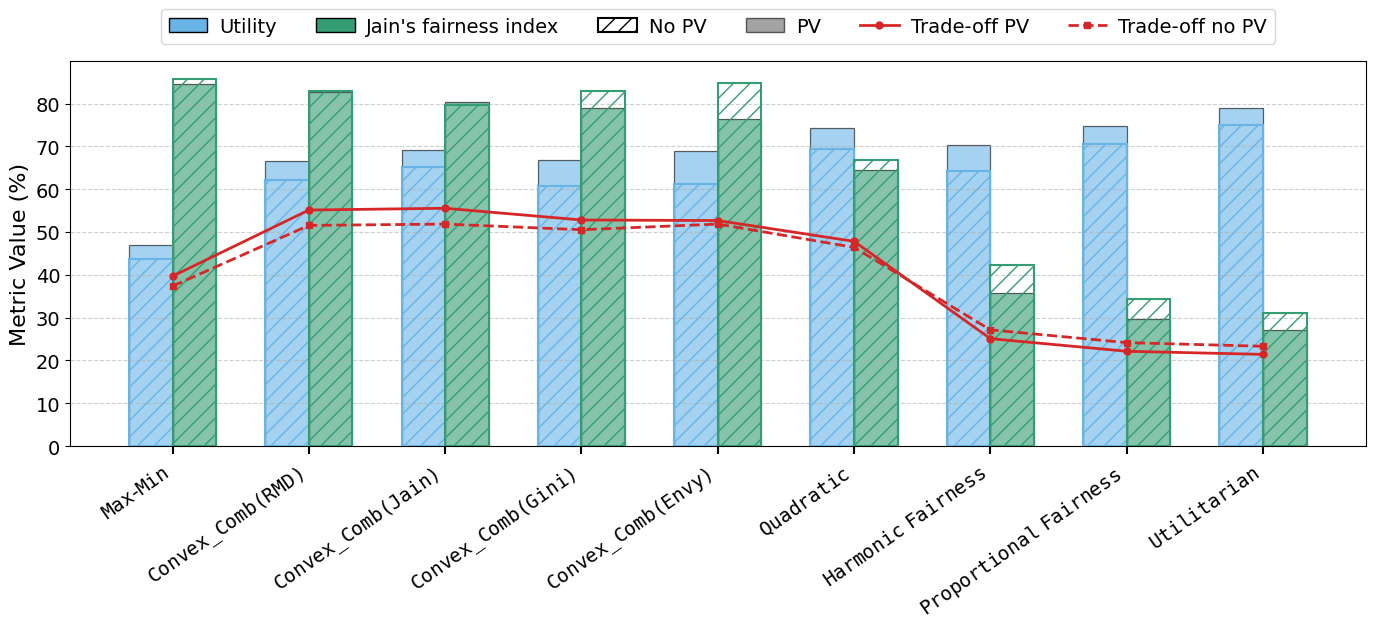

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import sys
sys.path.insert(0, '.')
from analysize import get_variables, flatten_result

df_pv_metrics = pd.read_csv('output_comb.csv')
if 'Group' not in df_pv_metrics.columns:
    df_pv_metrics.insert(1, 'Group', (df_pv_metrics['Instance_Number'] - 1) // 10 + 1)
df_pv_metrics['Objective_Index'] = df_pv_metrics['Objective_Index'].astype(int)

df_no_pv_metrics = pd.read_csv('output_comb_nopv.csv')
if 'Group' not in df_no_pv_metrics.columns:
    df_no_pv_metrics.insert(1, 'Group', (df_no_pv_metrics['Instance_Number'] - 1) // 10 + 1)
df_no_pv_metrics['Objective_Index'] = df_no_pv_metrics['Objective_Index'].astype(int)

exclude_groups = {3, 6}
df_pv_metrics = df_pv_metrics[~df_pv_metrics['Group'].isin(exclude_groups)].copy()
df_no_pv_metrics = df_no_pv_metrics[~df_no_pv_metrics['Group'].isin(exclude_groups)].copy()

OBJECTIVE_NAMES = [
    r'$\mathtt{Utilitarian}$',
    r'$\mathtt{Quadratic}$',
    '$\\mathtt{Proportional\\ Fairness}$',
    '$\\mathtt{Harmonic\\ Fairness}$',
    '$\\mathtt{Max}$-$\\mathtt{Min}$',
    r'$\mathtt{Convex\_Comb (RMD)}$',
    r'$\mathtt{Convex\_Comb (Gini)}$',
    r'$\mathtt{Convex\_Comb (Jain)}$',
    r'$\mathtt{Convex\_Comb (Envy)}$',
    '$\\mathtt{Egalitarian}$\n$\\mathtt{(No\\ Charging)}$',
]

objective_order = [
    '$\\mathtt{Max}$-$\\mathtt{Min}$',
    r'$\mathtt{Convex\_Comb (RMD)}$', r'$\mathtt{Convex\_Comb (Jain)}$',
    r'$\mathtt{Convex\_Comb (Gini)}$', r'$\mathtt{Convex\_Comb (Envy)}$',
    r'$\mathtt{Quadratic}$', '$\\mathtt{Harmonic\\ Fairness}$',
    '$\\mathtt{Proportional\\ Fairness}$', r'$\mathtt{Utilitarian}$'
]

def prepare_metrics(df_metrics, group_id=None):
    dfm = df_metrics.copy()
    if group_id is not None and "Group" in dfm.columns:
        dfm = dfm[dfm["Group"] == group_id].copy()
    
    agg_results = dfm.groupby("Objective_Index", as_index=False).agg({
        "Metrics_Utility": lambda s: 100.0 - s.mean(skipna=True) * 100.0,
        "Metrics_Jain's Fairness Index": lambda s: s.mean(skipna=True) * 100.0,
    })
    
    agg_results["Objective"] = agg_results["Objective_Index"].map(
        lambda x: OBJECTIVE_NAMES[x] if x < len(OBJECTIVE_NAMES) else str(x)
    )
    return agg_results

data_pv = prepare_metrics(df_pv_metrics, group_id=None)
data_no_pv = prepare_metrics(df_no_pv_metrics, group_id=None)

common = set(data_pv["Objective"]).intersection(set(data_no_pv["Objective"]))
final_order = [name for name in objective_order if name in common]

def align_data(df):
    df = df[df["Objective"].isin(final_order)].copy()
    df["Objective"] = pd.Categorical(df["Objective"], categories=final_order, ordered=True)
    return df.sort_values("Objective").reset_index(drop=True)

data_pv = align_data(data_pv)
data_no_pv = align_data(data_no_pv)

data_pv['Tradeoff'] = np.sqrt(data_pv["Metrics_Utility"] * data_pv["Metrics_Jain's Fairness Index"])
data_no_pv['Tradeoff'] = np.sqrt(data_no_pv["Metrics_Utility"] * data_no_pv["Metrics_Jain's Fairness Index"])

AXIS_LABEL_FONTSIZE = 16
TICK_LABEL_FONTSIZE = 14
LEGEND_FONTSIZE = 14

fig, ax = plt.subplots(figsize=(14, 7))

n = len(final_order)
x = np.arange(n)
bar_width = 0.32
utility_pos = x - bar_width / 2
jain_pos = x + bar_width / 2

colors = {
    "utility": "#68b4e7",
    "jain": "#349d74",
}
TRADEOFF_COLOR = "#d62728"

pv_utility = data_pv["Metrics_Utility"].values
pv_fairness = data_pv["Metrics_Jain's Fairness Index"].values
no_pv_utility = data_no_pv["Metrics_Utility"].values
no_pv_fairness = data_no_pv["Metrics_Jain's Fairness Index"].values

ax.bar(
    utility_pos,
    pv_utility,
    width=bar_width,
    color=colors["utility"],
    alpha=0.6,
    edgecolor="black",
    linewidth=0.9,
    zorder=1,
)
ax.bar(
    utility_pos,
    no_pv_utility,
    width=bar_width,
    color="none",
    edgecolor=colors["utility"],
    linewidth=1.3,
    hatch="//",
    alpha=1.0,
    zorder=2,
)
ax.bar(
    utility_pos,
    no_pv_utility,
    width=bar_width,
    color="none",
    edgecolor=colors["utility"],
    linewidth=1.5,
    zorder=3,
)

ax.bar(
    jain_pos,
    pv_fairness,
    width=bar_width,
    color=colors["jain"],
    alpha=0.6,
    edgecolor="black",
    linewidth=0.9,
    zorder=1,
)
ax.bar(
    jain_pos,
    no_pv_fairness,
    width=bar_width,
    color="none",
    edgecolor=colors["jain"],
    linewidth=1.3,
    hatch="//",
    alpha=1.0,
    zorder=2,
)
ax.bar(
    jain_pos,
    no_pv_fairness,
    width=bar_width,
    color="none",
    edgecolor=colors["jain"],
    linewidth=1.5,
    zorder=3,
)

tradeoff_pv = (pv_utility/100 * pv_fairness/100) * 100
tradeoff_no = (no_pv_utility/100 * no_pv_fairness/100) * 100
ax.plot(
    x,
    tradeoff_pv,
    color=TRADEOFF_COLOR,
    linestyle="-",
    marker="o",
    markersize=5,
    linewidth=2.0,
    zorder=6,
    label="Trade-off PV",
)
ax.plot(
    x,
    tradeoff_no,
    color=TRADEOFF_COLOR,
    linestyle="--",
    marker="s",
    markersize=5,
    linewidth=2.0,
    zorder=6,
    label="Trade-off no PV",
)

ax.set_ylabel("Metric Value (%)", fontsize=AXIS_LABEL_FONTSIZE)
ax.set_xticks(x)
ax.set_xticklabels(final_order, rotation=35, ha="right", fontsize=TICK_LABEL_FONTSIZE)
ax.tick_params(axis="x", which="major", pad=6, labelsize=TICK_LABEL_FONTSIZE, length=6, width=1.5)
ax.tick_params(axis="y", labelsize=TICK_LABEL_FONTSIZE)
ax.grid(axis="y", linestyle="--", alpha=0.6)

legend_handles = [
    Patch(facecolor=colors["utility"], edgecolor="black", label="Utility"),
    Patch(facecolor=colors["jain"], edgecolor="black", label="Jain's fairness index"),
    Patch(
        facecolor="white",
        edgecolor="black",
        hatch="//",
        linewidth=1.5,
        label="No PV",
    ),
    Patch(facecolor="#666666", edgecolor="black", alpha=0.6, label="PV"),
    Line2D(
        [0],
        [0],
        color=TRADEOFF_COLOR,
        linewidth=2.0,
        marker="o",
        markersize=5,
        label="Trade-off PV",
    ),
    Line2D(
        [0],
        [0],
        color=TRADEOFF_COLOR,
        linewidth=2.0,
        linestyle="--",
        marker="s",
        markersize=5,
        label="Trade-off no PV",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=len(legend_handles),
    handletextpad=0.6,
    fontsize=LEGEND_FONTSIZE,
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('utility_fairness_tradeoff_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Preparing data (full case)...
Data prepared: 344 rows (objective 9 excluded)


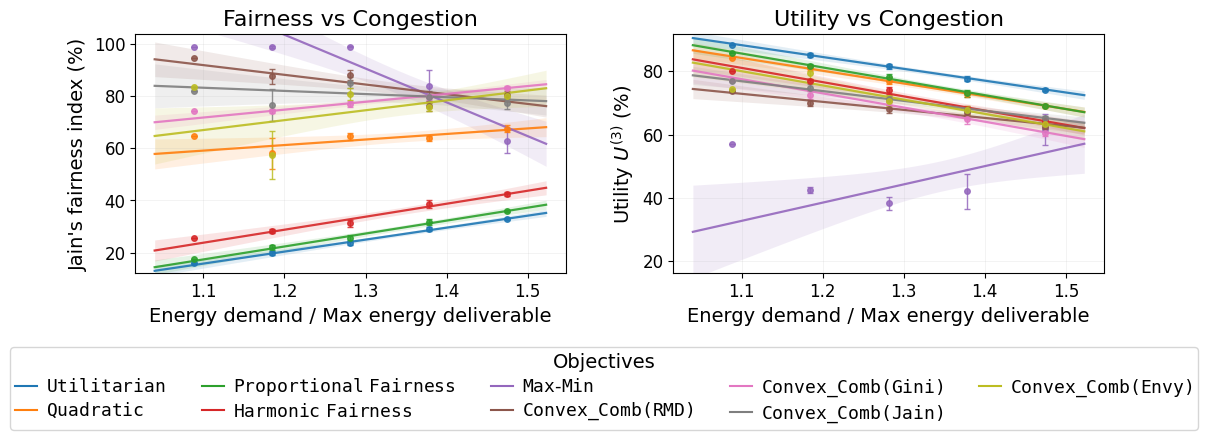

Plot saved as: comb_fairness_utility_full_binned_means.png


In [ ]:
import ast
import statistics
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

METHOD = "comb"
OBJECTIVE_LABELS = {
    0: r'$\mathtt{Utilitarian}$',
    1: r'$\mathtt{Quadratic}$',
    2: '$\\mathtt{Proportional\\ Fairness}$',
    3: '$\\mathtt{Harmonic\\ Fairness}$',
    4: '$\\mathtt{Max}$-$\\mathtt{Min}$',
    5: r'$\mathtt{Convex\_Comb (RMD)}$',
    6: r'$\mathtt{Convex\_Comb (Gini)}$',
    7: r'$\mathtt{Convex\_Comb (Jain)}$',
    8: r'$\mathtt{Convex\_Comb (Envy)}$',
    # 9: '$\\mathtt{Egalitarian}\\ \\mathtt{(No\\ Charging)}$',
}

TITLE_FONTSIZE = 16
AXIS_LABEL_FONTSIZE = 14
TICK_LABEL_FONTSIZE = 12
LEGEND_FONTSIZE = 14


def _numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")


def _parse_list(value):
    """Parse a list from string or return empty list."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return []
    if isinstance(value, (list, tuple, np.ndarray)):
        return [float(x) for x in value]
    text = str(value).strip()
    if not text:
        return []
    if text.startswith("[") and text.endswith("]"):
        try:
            parsed = ast.literal_eval(text)
        except (SyntaxError, ValueError):
            parsed = []
        if isinstance(parsed, (list, tuple)):
            return [float(x) for x in parsed]
    try:
        return [float(x.strip()) for x in text.split(",") if x.strip()]
    except Exception:
        return []


def _compute_full_metrics(socs: pd.DataFrame) -> pd.DataFrame:
    """Compute metrics for all vehicles (full demand)."""
    inst_col = "instance" if "instance" in socs.columns else "Instance_Number"
    obj_col = "Objective_Index" if "Objective_Index" in socs.columns else "objective"
    rows = []
    for _, row in socs.iterrows():
        inst = pd.to_numeric(row.get(inst_col), errors="coerce")
        obj = pd.to_numeric(row.get(obj_col), errors="coerce")
        if pd.isna(inst) or pd.isna(obj):
            continue

        initial = _parse_list(row.get("initial_soc_list"))
        desired = _parse_list(row.get("desired_soc_list"))
        battery = _parse_list(row.get("battery_capacity_list"))
        final = _parse_list(row.get("final_soc_list"))
        if not final:
            final = _parse_list(row.get("soc_list"))

        length = min(len(initial), len(desired), len(battery), len(final))
        if length == 0:
            continue

        initial = np.array(initial[:length], dtype=float)
        desired = np.array(desired[:length], dtype=float)
        battery = np.array(battery[:length], dtype=float)
        final = np.array(final[:length], dtype=float)

        denom = desired - initial
        valid = denom > 0
        delivered = np.full_like(final, np.nan, dtype=float)
        shortfall = np.full_like(final, np.nan, dtype=float)
        delivered[valid] = (final[valid] - initial[valid]) / denom[valid]
        shortfall[valid] = (desired[valid] - final[valid]) / denom[valid]

        e_req = (((desired - initial) / 100.0) * battery).sum()
        u_vals = delivered[np.isfinite(delivered)]
        fair_vals = shortfall[np.isfinite(shortfall)]

        if u_vals.size == 0:
            u_mean = np.nan
            jain = np.nan
        else:
            sum_f = fair_vals.sum()
            sum_f_sq = (fair_vals * fair_vals).sum()
            if sum_f_sq > 0:
                jain = (sum_f * sum_f) / (fair_vals.size * sum_f_sq)
            else:
                jain = 1.0
            u_mean = float(u_vals.mean())

        rows.append(
            {
                "Instance_Number": int(inst),
                "Objective_Index": int(obj),
                "method": METHOD,
                "E_req_kWh_full": e_req,
                "Metrics_Utility_full": u_mean,
                "Metrics_Jain_full": jain,
            }
        )

    return pd.DataFrame(rows)


def _prepare_full(combined_path: str = "output_comb.csv") -> pd.DataFrame:
    """Prepare data with full metrics and congestion ratio using output_comb.csv only."""
    socs = pd.read_csv(combined_path)
    full = _compute_full_metrics(socs)

    required_capacity_cols = ["w_G", "horizon_hours", "pv_total_kWh"]
    missing = [c for c in required_capacity_cols if c not in socs.columns]
    if missing:
        raise ValueError(
            "output_comb.csv is missing capacity columns "
            f"{missing}. Re-run the first cell with the 'comb' method enabled."
        )

    cap_cols = ["Instance_Number", "Objective_Index"] + required_capacity_cols
    if "capacity_total_kWh" in socs.columns:
        cap_cols.append("capacity_total_kWh")

    capacity_df = socs[cap_cols].copy()
    capacity_df["Instance_Number"] = pd.to_numeric(capacity_df["Instance_Number"], errors="coerce")
    capacity_df["Objective_Index"] = pd.to_numeric(capacity_df["Objective_Index"], errors="coerce")
    capacity_df = capacity_df.dropna(subset=["Instance_Number", "Objective_Index"]).copy()
    capacity_df["Instance_Number"] = capacity_df["Instance_Number"].astype(int)
    capacity_df["Objective_Index"] = capacity_df["Objective_Index"].astype(int)

    for col in required_capacity_cols:
        capacity_df[col] = _numeric(capacity_df[col])
    if "capacity_total_kWh" in capacity_df.columns:
        capacity_df["capacity_total_kWh"] = _numeric(capacity_df["capacity_total_kWh"])

    capacity_df = capacity_df.drop_duplicates(
        subset=["Instance_Number", "Objective_Index"],
        keep="last",
    )

    df = full.merge(capacity_df, on=["Instance_Number", "Objective_Index"], how="left")

    if "capacity_total_kWh" in df.columns:
        capacity = _numeric(df["capacity_total_kWh"]).replace(0, np.nan)
    else:
        pv_energy = _numeric(df["pv_total_kWh"]).fillna(0.0)
        w_g_vals = _numeric(df["w_G"]).fillna(0.0)
        horizon = _numeric(df["horizon_hours"]).fillna(0.0)
        capacity = (w_g_vals * horizon + pv_energy).replace(0, np.nan)

    df["congestion_ratio"] = _numeric(df["E_req_kWh_full"]) / capacity
    df = df.replace([np.inf, -np.inf], np.nan)

    return df.dropna(subset=["congestion_ratio", "Objective_Index", "Metrics_Jain_full", "Metrics_Utility_full"])


def _objective_coloring(objectives):
    """Create colormap for objective indices."""
    obj_list = sorted(set(int(o) for o in objectives))
    if not obj_list:
        raise ValueError("No objective indices provided")

    min_obj = min(obj_list)
    max_obj = max(obj_list)
    n_obj = max_obj - min_obj + 1

    base = plt.get_cmap("tab10" if n_obj <= 10 else "tab20")
    colors = [base(i % base.N) for i in range(n_obj)]
    cmap = mcolors.ListedColormap(colors, name="objective_index")
    boundaries = np.arange(min_obj - 0.5, max_obj + 1.5, 1.0)
    norm = mcolors.BoundaryNorm(boundaries=boundaries, ncolors=cmap.N, clip=True)
    ticks = list(range(min_obj, max_obj + 1))

    return {"cmap": cmap, "norm": norm, "ticks": ticks}


def _add_regression_lines(ax, x, y, obj, coloring, *, ci_level=0.95):
    """Add regression lines with confidence intervals."""
    use_ci = ci_level is not None and 0.0 < ci_level < 1.0
    if use_ci:
        z = statistics.NormalDist().inv_cdf(0.5 + ci_level / 2.0)

    for objective in sorted(set(int(v) for v in obj)):
        mask = obj == objective
        if mask.sum() < 2:
            continue
        x_sub = x[mask]
        y_sub = y[mask]
        finite = np.isfinite(x_sub) & np.isfinite(y_sub)
        if finite.sum() < 2:
            continue
        x_sub = x_sub[finite]
        y_sub = y_sub[finite]
        if np.isclose(x_sub.max(), x_sub.min()):
            continue
        slope, intercept = np.polyfit(x_sub, y_sub, 1)
        x_line = np.linspace(x_sub.min(), x_sub.max(), 50)
        y_line = slope * x_line + intercept
        color = coloring["cmap"](coloring["norm"](int(objective)))
        ax.plot(x_line, y_line, color=color, linewidth=1.6, alpha=0.9)

        if use_ci and x_sub.size > 2:
            y_hat = slope * x_sub + intercept
            resid = y_sub - y_hat
            sse = np.sum(resid * resid)
            sxx = np.sum((x_sub - x_sub.mean()) ** 2)
            if sxx > 0.0:
                s = np.sqrt(sse / (x_sub.size - 2))
                se_mean = s * np.sqrt(1.0 / x_sub.size + (x_line - x_sub.mean()) ** 2 / sxx)
                band = z * se_mean
                lower = y_line - band
                upper = y_line + band
                ax.fill_between(x_line, lower, upper, color=color, alpha=0.12, linewidth=0)


def _compute_bin_edges(x, bins=5):
    """Compute bin edges for binning."""
    finite = x[np.isfinite(x)]
    if finite.size < 2:
        return None
    xmin = float(finite.min())
    xmax = float(finite.max())
    if np.isclose(xmin, xmax):
        return None
    return np.linspace(xmin, xmax, bins + 1)


def _plot_binned_means(ax, x, y, obj, coloring, *, edges=None):
    """Plot binned means with error bars."""
    if edges is None:
        return
    df = pd.DataFrame({"x": x, "y": y, "obj": obj})
    centers = (edges[:-1] + edges[1:]) / 2.0
    for objective in sorted(set(int(v) for v in obj)):
        sub = df[df["obj"] == objective].dropna()
        if sub.shape[0] < 3:
            continue
        sub = sub.assign(bin_idx=pd.cut(sub["x"], bins=edges, include_lowest=True, labels=False))
        grouped = sub.groupby("bin_idx", observed=True)
        means = grouped["y"].mean()
        counts = grouped["y"].count()
        std = grouped["y"].std(ddof=1).fillna(0.0)
        se = std / np.sqrt(counts)
        color = coloring["cmap"](coloring["norm"](int(objective)))
        x_vals = centers[means.index.to_numpy(dtype=int)]
        ax.errorbar(
            x_vals,
            means.to_numpy(),
            yerr=se.to_numpy(),
            fmt="o",
            markersize=4,
            color=color,
            alpha=0.85,
            linewidth=1.0,
            capsize=2,
        )


def _y_limits(values):
    """Compute y-axis limits with padding."""
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return 0.0, 1.0
    ymin = float(finite.min())
    ymax = float(finite.max())
    if np.isclose(ymin, ymax):
        pad = 0.05 if ymin == 0.0 else abs(ymin) * 0.05
        return ymin - pad, ymax + pad
    pad = 0.05 * (ymax - ymin)
    return ymin - pad, ymax + pad


def _add_objective_legend(fig, coloring):
    """Add objective legend at the bottom (same format as reference figure)."""
    handles = []
    for obj in coloring["ticks"]:
        label = OBJECTIVE_LABELS.get(int(obj), f"Obj {obj}")
        color = coloring["cmap"](coloring["norm"](int(obj)))
        handles.append(Line2D([0], [0], color=color, lw=1.5, label=label))
    fig.legend(
        handles=handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.0),
        ncol=5,
        fontsize=13,
        title="Objectives",
        title_fontsize=14,
        handlelength=1.2,
        handletextpad=0.5,
        borderpad=0.3,
        labelspacing=0.25,
    )


print("Preparing data (full case)...")
df = _prepare_full("output_comb.csv")
df = df[df["Objective_Index"] != 9].copy()
print(f"Data prepared: {len(df)} rows (objective 9 excluded)")

coloring = _objective_coloring(df["Objective_Index"].dropna().astype(int))

plt.rcParams.update(
    {
        "axes.titlesize": TITLE_FONTSIZE,
        "axes.labelsize": AXIS_LABEL_FONTSIZE,
        "xtick.labelsize": TICK_LABEL_FONTSIZE,
        "ytick.labelsize": TICK_LABEL_FONTSIZE,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), constrained_layout=False, sharex=True)
fig.subplots_adjust(bottom=0.36, wspace=0.25)

ax = axes[0]
x = _numeric(df["congestion_ratio"]).to_numpy()
y_jain = _numeric(df["Metrics_Jain_full"]).to_numpy() * 100.0
obj = _numeric(df["Objective_Index"]).astype(int).to_numpy()

bins = 5
edges = _compute_bin_edges(x, bins=bins)
_plot_binned_means(ax, x, y_jain, obj, coloring, edges=edges)
_add_regression_lines(ax, x, y_jain, obj, coloring, ci_level=0.95)

ax.set_title("Fairness vs Congestion", fontsize=TITLE_FONTSIZE)
ax.set_ylabel("Jain's fairness index (%)", fontsize=AXIS_LABEL_FONTSIZE)
ax.tick_params(axis="both", labelsize=TICK_LABEL_FONTSIZE)
ax.set_ylim(*_y_limits(y_jain))
ax.grid(alpha=0.2, linewidth=0.5)

ax = axes[1]
y_util = _numeric(df["Metrics_Utility_full"]).to_numpy() * 100.0

_plot_binned_means(ax, x, y_util, obj, coloring, edges=edges)
_add_regression_lines(ax, x, y_util, obj, coloring, ci_level=0.95)

ax.set_title("Utility vs Congestion", fontsize=TITLE_FONTSIZE)
ax.set_ylabel(r"Utility $U^{(3)}$ (%)", fontsize=AXIS_LABEL_FONTSIZE)
ax.tick_params(axis="both", labelsize=TICK_LABEL_FONTSIZE)
ax.set_ylim(*_y_limits(y_util))
ax.grid(alpha=0.2, linewidth=0.5)

xlabel = "Energy demand / Max energy deliverable"
axes[0].set_xlabel(xlabel, fontsize=AXIS_LABEL_FONTSIZE)
axes[1].set_xlabel(xlabel, fontsize=AXIS_LABEL_FONTSIZE)

_add_objective_legend(fig, coloring)

plt.savefig("comb_fairness_utility_full_binned_means.png", dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as: comb_fairness_utility_full_binned_means.png")

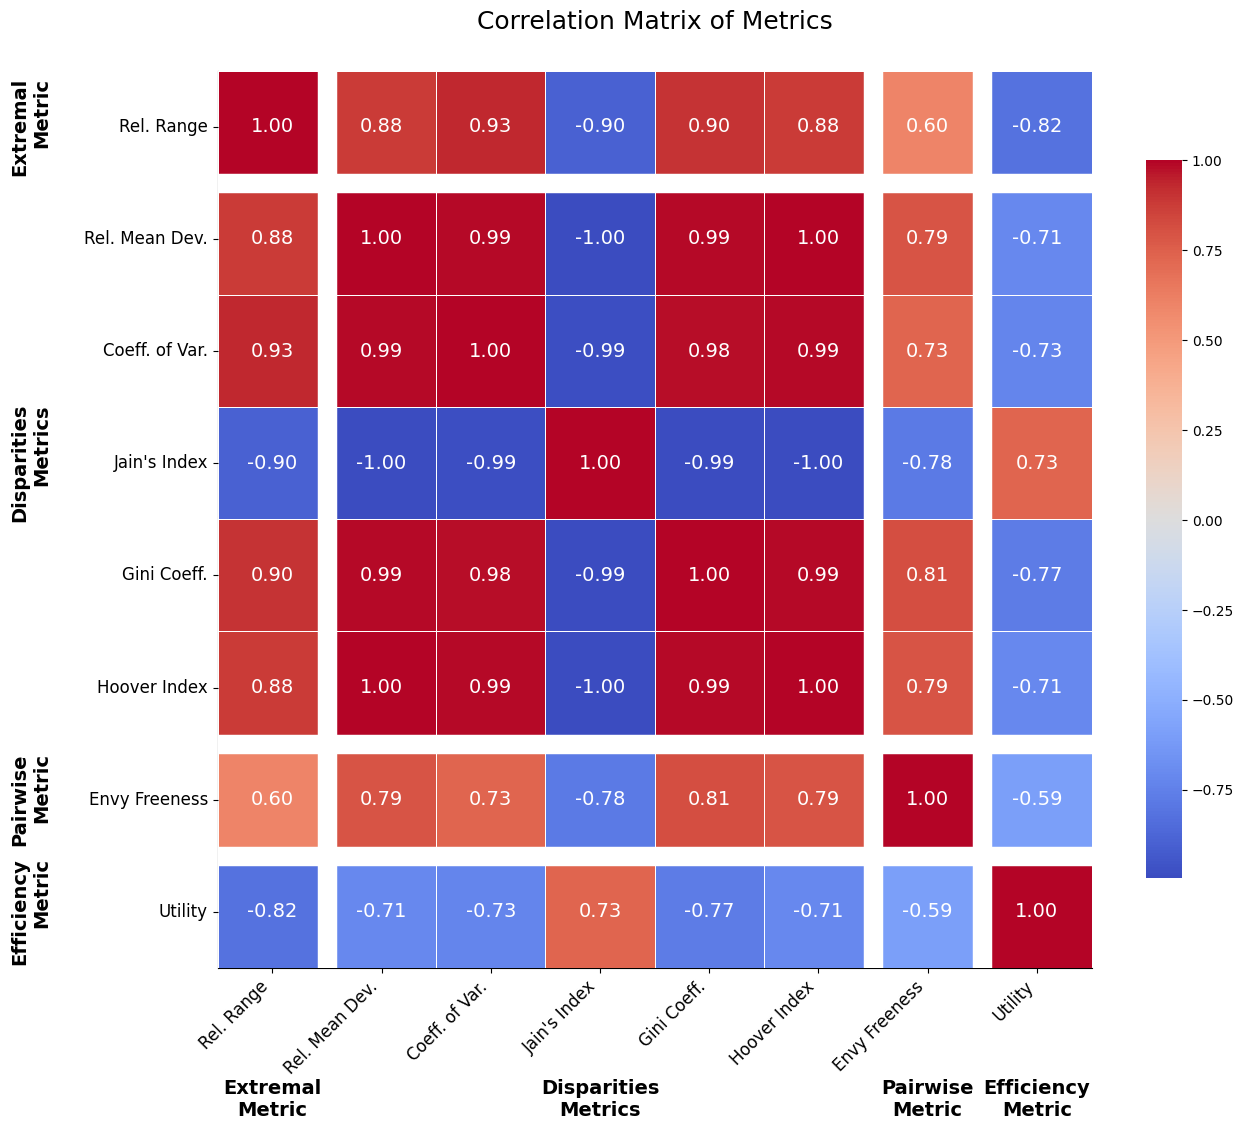

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df_mip = pd.read_csv('output_mip.csv')
df_comb = pd.read_csv('output_comb.csv')
df_h_lns = pd.read_csv('output_h_lns.csv')
df_h = pd.read_csv('output_h.csv')

combined_df = pd.concat([df_mip, df_comb, df_h_lns, df_h], ignore_index=True)

group1_metrics = ['Metrics_Relative Range']
group2_disparity_metrics = [
    'Metrics_Relative Mean Deviation',      # RMD
    'Metrics_Coefficient of Variation',     # Coeff of Var
    "Metrics_Jain's Fairness Index",        # Jain
    'Metrics_Gini Coefficient',             # Gini
    'Metrics_Hoover Index',                 # Hoover
]
group3_metrics = ['Metrics_Envy Freeness']
group4_metrics = ['Metrics_Utility']

ordered_metrics = group1_metrics + group2_disparity_metrics + group3_metrics + group4_metrics

metrics_df = combined_df[ordered_metrics]

new_column_names = {
    'Metrics_Envy Freeness': 'Envy Freeness',
    'Metrics_Relative Mean Deviation': 'Rel. Mean Dev.',
    'Metrics_Gini Coefficient': 'Gini Coeff.',
    "Metrics_Jain's Fairness Index": "Jain's Index",
    'Metrics_Relative Range': 'Rel. Range',
    'Metrics_Coefficient of Variation': 'Coeff. of Var.',
    'Metrics_Hoover Index': 'Hoover Index',
    'Metrics_Utility': 'Utility'
}
metrics_df = metrics_df.rename(columns=new_column_names)

correlation_matrix = metrics_df.corr()

fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    annot_kws={"size": 14},
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

separator_indices = [
    len(group1_metrics),
    len(group1_metrics) + len(group2_disparity_metrics),
    len(group1_metrics) + len(group2_disparity_metrics) + len(group3_metrics)
]

for index in separator_indices:
    ax.axhline(y=index, color='white', linewidth=14)
    ax.axvline(x=index, color='white', linewidth=14)

group_boundaries = [0] + separator_indices + [len(ordered_metrics)]
group_centers = [(group_boundaries[i] + group_boundaries[i+1]) / 2 for i in range(len(group_boundaries) - 1)]

group_labels_x = group_labels_y = ["Extremal\nMetric", "Disparities\nMetrics", "Pairwise\nMetric", "Efficiency\nMetric"]

secax_x = ax.secondary_xaxis('bottom')
secax_x.set_xticks(group_centers)
secax_x.set_xticklabels(group_labels_x, fontsize=14, fontweight='bold')
secax_x.tick_params(axis='x', length=0, pad=80)

secax_y = ax.secondary_yaxis('left')
secax_y.set_yticks(group_centers)
secax_y.set_yticklabels(group_labels_y, fontsize=14, fontweight='bold', rotation=90, va='center')
secax_y.tick_params(axis='y', length=0, pad=120)

ax.set_title('Correlation Matrix of Metrics', fontsize=18, pad=30)
ax.tick_params(axis='x', labelsize=12, labelrotation=45)
ax.tick_params(axis='y', labelsize=12, labelrotation=0)
for label in ax.get_xticklabels():
    label.set_ha('right')

plt.tight_layout(rect=[0.05, 0, 1, 0.95])
plt.savefig('correlation_matrix_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

Rows: 660
Rows with paired diff: 660
Unique lambdas: 11 | Instances: 60


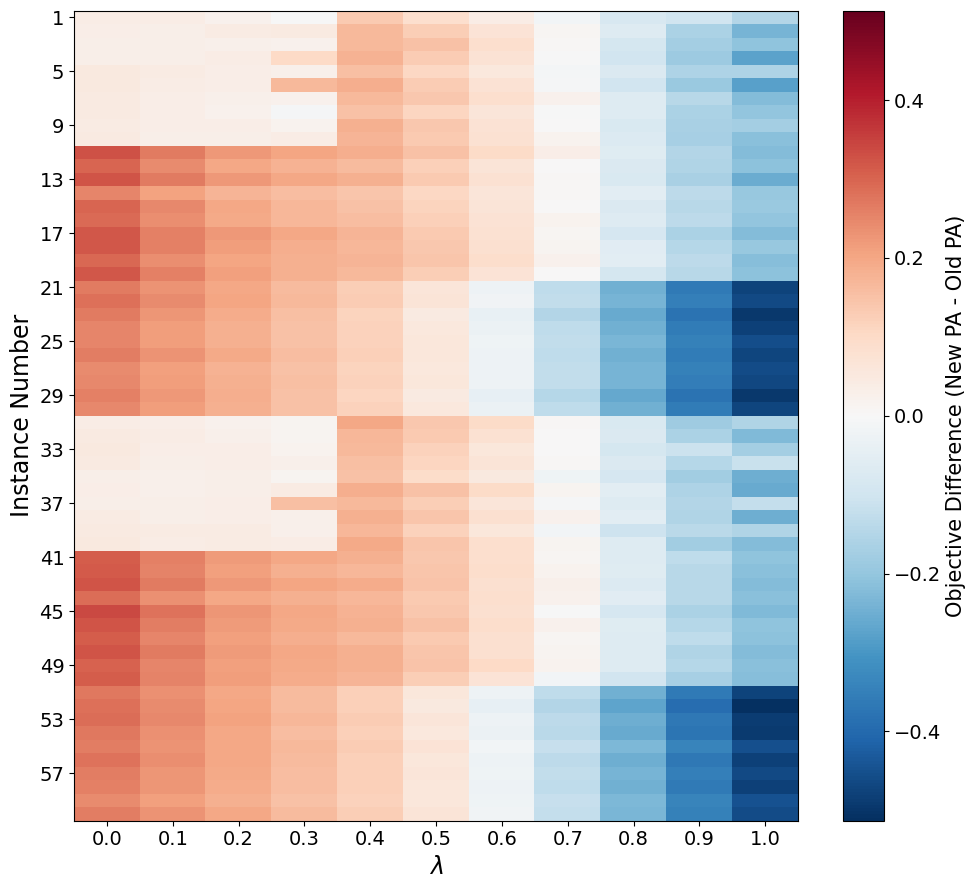

Saved: plot_obj_diff_heatmap_instance_lambda.png


In [ ]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AXIS_LABEL_FONTSIZE = 17
TICK_LABEL_FONTSIZE = 14
CBar_LABEL_FONTSIZE = 15


def build_pa_paired_df_from_csv(csv_path='output_pa_lambda_obj6.csv', objective=6):
    """
    Build paired DataFrame from aggregated CSV:
      columns = instance, lambda, obj_pa0, obj_pa1, obj_diff_pa1_minus_pa0

    Pairing is done on (instance, lambda), with pa in {0,1}, so lambda and pa
    variations are both preserved.
    """
    csv_path = Path(csv_path)
    if not csv_path.is_file():
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    df_raw = pd.read_csv(csv_path)

    required_cols = {'Filename', 'Additional infos_obj'}
    missing = required_cols.difference(df_raw.columns)
    if missing:
        raise ValueError(f"CSV missing required columns: {sorted(missing)}")

    pattern = re.compile(
        r"solution_(?P<instance>\d+)_obj=(?P<objective>\d+)_lambda=(?P<lambda>[\d.]+)_pa=(?P<pa>[01])_lns\.log$"
    )

    extracted = df_raw['Filename'].astype(str).str.extract(pattern)
    df = pd.concat([df_raw, extracted], axis=1)
    df = df.dropna(subset=['instance', 'objective', 'lambda', 'pa']).copy()

    df['instance'] = pd.to_numeric(df['instance'], errors='coerce').astype('Int64')
    df['objective'] = pd.to_numeric(df['objective'], errors='coerce').astype('Int64')
    df['lambda'] = pd.to_numeric(df['lambda'], errors='coerce')
    df['pa'] = pd.to_numeric(df['pa'], errors='coerce').astype('Int64')
    df['obj_value'] = pd.to_numeric(df['Additional infos_obj'], errors='coerce')

    df = df[df['objective'] == objective].copy()
    if df.empty:
        raise ValueError(f"No rows found in {csv_path} for objective={objective}")

    df = df.drop_duplicates(subset=['instance', 'lambda', 'pa'], keep='last')

    paired = (
        df.pivot_table(
            index=['instance', 'lambda'],
            columns='pa',
            values='obj_value',
            aggfunc='first'
        )
        .rename(columns={0: 'obj_pa0', 1: 'obj_pa1'})
        .reset_index()
    )

    if 'obj_pa0' not in paired.columns:
        paired['obj_pa0'] = np.nan
    if 'obj_pa1' not in paired.columns:
        paired['obj_pa1'] = np.nan

    paired['obj_diff_pa1_minus_pa0'] = paired['obj_pa1'] - paired['obj_pa0']

    paired = paired[[
        'instance', 'lambda', 'obj_pa0', 'obj_pa1', 'obj_diff_pa1_minus_pa0'
    ]].sort_values(['instance', 'lambda']).reset_index(drop=True)

    return paired


def plot_obj_diff_heatmap_instance_lambda(df, output_path=None, figsize=(10, 9), dpi=300):
    """
    Plot per-instance/lambda heatmap of obj diff (pa=1 - pa=0).
    df must contain: instance, lambda, obj_diff_pa1_minus_pa0
    """
    required = {'instance', 'lambda', 'obj_diff_pa1_minus_pa0'}
    missing = required.difference(df.columns)
    if missing:
        raise ValueError(f"DataFrame missing columns: {sorted(missing)}")

    df_plot = df.dropna(subset=['obj_diff_pa1_minus_pa0'])
    if df_plot.empty:
        raise ValueError('No non-NaN obj_diff_pa1_minus_pa0 to build heatmap.')

    matrix = (
        df_plot.pivot(index='instance', columns='lambda', values='obj_diff_pa1_minus_pa0')
        .sort_index()
        .sort_index(axis=1)
    )

    values = matrix.to_numpy(dtype=float)
    vmax = float(np.nanmax(np.abs(values)))
    if not np.isfinite(vmax) or vmax == 0.0:
        vmax = 1.0

    fig, ax = plt.subplots(figsize=figsize)
    img = ax.imshow(values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    cbar = fig.colorbar(img, ax=ax)
    cbar.set_label('Objective Difference (New PA - Old PA)', fontsize=CBar_LABEL_FONTSIZE)
    cbar.ax.tick_params(labelsize=TICK_LABEL_FONTSIZE)

    lambdas = matrix.columns.tolist()
    instances = matrix.index.tolist()

    ax.set_xticks(np.arange(len(lambdas)))
    ax.set_xticklabels([f"{lam:.1f}" for lam in lambdas], rotation=0)

    if len(instances) <= 20:
        y_idx = np.arange(len(instances))
    else:
        step = max(1, len(instances) // 15)
        y_idx = np.arange(0, len(instances), step)
    ax.set_yticks(y_idx)
    ax.set_yticklabels([str(instances[i]) for i in y_idx])

    ax.set_xlabel(r'$\lambda$', fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel('Instance Number', fontsize=AXIS_LABEL_FONTSIZE)
    ax.tick_params(axis='both', labelsize=TICK_LABEL_FONTSIZE)
    fig.tight_layout()

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, dpi=dpi, bbox_inches='tight')

    return fig, ax


csv_pa = 'output_pa_lambda_obj6.csv'
df_pa_paired = build_pa_paired_df_from_csv(csv_pa, objective=6)

print(f"Rows: {len(df_pa_paired)}")
print(f"Unique lambdas: {df_pa_paired['lambda'].nunique()} | Instances: {df_pa_paired['instance'].nunique()}")

fig, ax = plot_obj_diff_heatmap_instance_lambda(
    df_pa_paired,
    output_path='plot_obj_diff_heatmap_instance_lambda.png'
)
plt.show()
print('Saved: plot_obj_diff_heatmap_instance_lambda.png')